In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from timeit import default_timer as time
from tqdm.auto import tqdm


data = pd.read_csv("house_data(1).csv")

print(data.head(10))
data.info()

      0      1        2      3
0  aria  rooms  ratings  price
1  1200      2      3.8     45
2  1500      3      4.2     62
3   850      1      3.5     32
4  2200      4      4.7     95
5  1100      2      3.2     41
6  1850      3        4     75
7  2600      5      4.9    125
8   950      2      3.1     36
9  1300      3      3.6     54
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       43 non-null     object
 1   1       43 non-null     object
 2   2       43 non-null     object
 3   3       43 non-null     object
dtypes: object(4)
memory usage: 1.5+ KB


In [97]:
data = pd.read_csv("house_data(1).csv")

new_header = data.iloc[0].tolist()
data = data[1:].copy()
data.columns = new_header

# Convert all columns to numeric, coercing errors to NaN
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop rows with NaN values that resulted from conversion issues
data.dropna(inplace=True)

X = data.drop('price',axis=1)
y = data['price']

print(X)
print(y)

    aria  rooms  ratings
1   1200      2      3.8
2   1500      3      4.2
3    850      1      3.5
4   2200      4      4.7
5   1100      2      3.2
6   1850      3      4.0
7   2600      5      4.9
8    950      2      3.1
9   1300      3      3.6
10  3100      5      4.8
11  1250      2      3.7
12  1600      3      4.1
13   800      1      3.0
14  2150      4      4.6
15  1050      2      3.3
16  1950      3      4.3
17  2700      5      4.8
18   920      2      3.4
19  1450      3      3.9
20  3300      5      4.9
21  1150      2      3.5
22  1550      3      4.0
23   880      1      3.2
24  2250      4      4.7
25  1000      2      3.0
26  2000      4      4.4
27  2800      5      4.7
28   980      2      3.6
29  1400      3      3.8
30  3500      5      5.0
31  1220      2      3.7
32  1650      3      4.2
33   820      1      3.1
34  2300      4      4.5
35  1080      2      3.4
36  1900      3      4.1
37  2900      5      4.9
38   940      2      3.5
39  1380      3      3.7


In [72]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [73]:
print(len(x_train))
print(len(y_train))
print(len(x_test))
print(len(y_test))
print(x_train.shape)
print(y_train.shape)

33
33
9
9
(33, 3)
(33,)


In [102]:
from numpy import seterrcall
import torch # Ensure torch is imported if not already

# Create a scaler for features (X_train, X_test)
feature_scaler = StandardScaler()
x_train = feature_scaler.fit_transform(x_train)
x_test = feature_scaler.transform(x_test)

# Create a separate scaler for the target variable (y_train, y_test)
target_scaler = StandardScaler()

# Ensure y_train and y_test are numpy arrays before scaling
# They might be Tensors if uCdAwaCwDFk8 was executed previously
if isinstance(y_train, torch.Tensor):
    y_train_np = y_train.cpu().numpy()
else:
    y_train_np = y_train.to_numpy()

if isinstance(y_test, torch.Tensor):
    y_test_np = y_test.cpu().numpy()
else:
    y_test_np = y_test.to_numpy()

y_train = target_scaler.fit_transform(y_train_np.reshape(-1, 1))
y_test = target_scaler.transform(y_test_np.reshape(-1, 1))

In [103]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x_train = torch.from_numpy(x_train).to(dtype=torch.float32).to(device)
y_train = torch.from_numpy(y_train).to(dtype=torch.float32).to(device)
x_test = torch.from_numpy(x_test).to(dtype=torch.float32).to(device)
y_test = torch.from_numpy(y_test).to(dtype=torch.float32).to(device)

In [104]:
class anshai(nn.Module):
    def __init__(self):
        super(anshai,self).__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(3,10),
            nn.ReLU(),
            nn.Linear(10,20),
            nn.ReLU(),
            nn.Linear(20,1)
        )
    def forward(self,x):
        return self.layer1(x)


In [105]:
def show_time(start:float,
              end:float,
              device: torch.cuda=None):
    total_time = end-start
    print(f"Total time taken on {device} is {total_time:.2f}")
    return total_time

In [80]:
torch.manual_seed(42)
model = anshai().to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)


In [123]:
epoch = 100
start = time()

# Initialize lists to store losses
train_losses = []
test_losses = []

for epochs in tqdm(range(epoch)):
    model.train()
    y_pred = model(x_train)
    loss = loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.inference_mode():
        test_pred = model(x_test)
        test_loss = loss_fn(test_pred,y_test)

    # Store losses for plotting
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epochs % 10 == 0:
        print(f"epoch: {epochs}\ntrain loss {loss.item():.2f}\ntest loss: {test_loss.item():.2f}")
end = time()
print(show_time(start=start,end=end, device=str(next(model.parameters()).device)))

  0%|          | 0/100 [00:00<?, ?it/s]

epoch: 0
train loss 0.00
test loss: 0.02
epoch: 10
train loss 0.00
test loss: 0.02
epoch: 20
train loss 0.00
test loss: 0.02
epoch: 30
train loss 0.00
test loss: 0.02
epoch: 40
train loss 0.00
test loss: 0.02
epoch: 50
train loss 0.00
test loss: 0.02
epoch: 60
train loss 0.00
test loss: 0.02
epoch: 70
train loss 0.00
test loss: 0.02
epoch: 80
train loss 0.00
test loss: 0.02
epoch: 90
train loss 0.00
test loss: 0.02
Total time taken on cpu is 0.17
0.16550596599881828


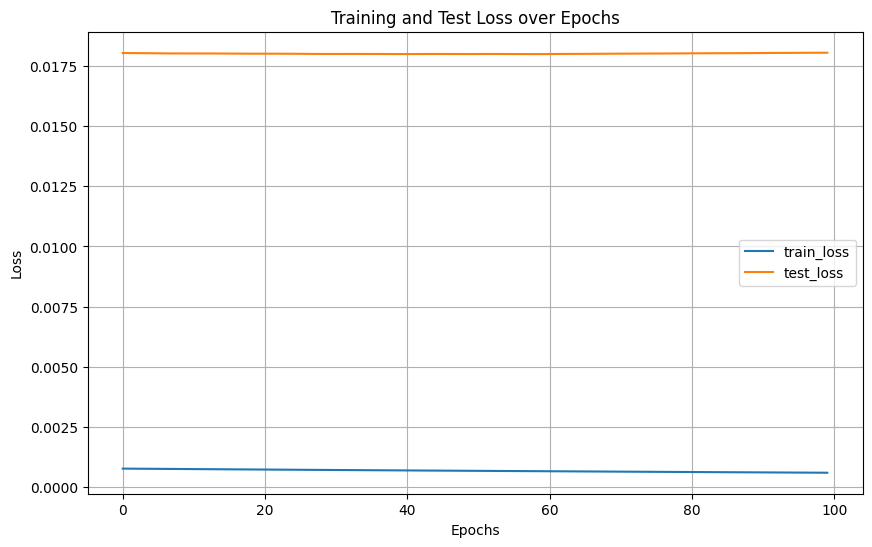

In [124]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="train_loss")
plt.plot(test_losses, label="test_loss")
plt.title("Training and Test Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [125]:
import os
os.mkdir("models")
path = "models/anshai.pth"
torch.save(model.state_dict(),f=path)
